<a href="https://colab.research.google.com/github/Noga-66/Brain_Tumor_project/blob/main/Brain_Tumor_Enhanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Brain Tumor Segmentation


## Step 1: Setup & Data Download

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"noga66","key":"dacf4e54f61e2ce24c1483f7a2efbf78"}'}

In [2]:
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json
! kaggle datasets download tinashri/brain-tumor-segmentation-datasets
! unzip -q 'brain-tumor-segmentation-datasets.zip'

Dataset URL: https://www.kaggle.com/datasets/tinashri/brain-tumor-segmentation-datasets
License(s): unknown
100% 312M/312M [00:01<00:00, 169MB/s]



In [4]:
! unzip 'brain-tumor-segmentation-datasets.zip'

Streaming output truncated to the last 5000 lines.
  inflating: data/images/2013.png    
  inflating: data/images/2014.png    
  inflating: data/images/2015.png    
  inflating: data/images/2016.png    
  inflating: data/images/2017.png    
  inflating: data/images/2018.png    
  inflating: data/images/2019.png    
  inflating: data/images/202.png     
  inflating: data/images/2020.png    
  inflating: data/images/2021.png    
  inflating: data/images/2022.png    
  inflating: data/images/2023.png    
  inflating: data/images/2024.png    
  inflating: data/images/2025.png    
  inflating: data/images/2026.png    
  inflating: data/images/2027.png    
  inflating: data/images/2028.png    
  inflating: data/images/2029.png    
  inflating: data/images/203.png     
  inflating: data/images/2030.png    
  inflating: data/images/2031.png    
  inflating: data/images/2032.png    
  inflating: data/images/2033.png    
  inflating: data/images/2034.png    
  inflating: data/images/2035.png    

##  Step 2: Import Libraries

In [5]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from glob import glob
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
)

# Fix random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style('darkgrid')
print(' All modules loaded successfully!')
print(f'TensorFlow version: {tf.__version__}')

 All modules loaded successfully!
TensorFlow version: 2.20.0


##  Step 3: Configuration

In [6]:
#  Global Config
IMG_HEIGHT   = 256
IMG_WIDTH    = 256
IMG_CHANNELS = 3

IMAGES_PATH  = '/content/data/images'
MASKS_PATH   = '/content/data/masks'

BATCH_SIZE   = 16
EPOCHS       = 30
LEARNING_RATE = 1e-4

# Crop region (remove black borders around brain scan)
CROP_Y1, CROP_Y2 = 90, 450
CROP_X1, CROP_X2 = 150, 406

print(f'Image size : {IMG_HEIGHT} x {IMG_WIDTH} x {IMG_CHANNELS}')
print(f'Batch size : {BATCH_SIZE}')
print(f'Max epochs : {EPOCHS}')

Image size : 256 x 256 x 3
Batch size : 16
Max epochs : 30


##  Step 4: Dataset Exploration (EDA)

In [7]:
image_files = sorted(os.listdir(IMAGES_PATH))
mask_files  = sorted(os.listdir(MASKS_PATH))

print(f'Total images : {len(image_files)}')
print(f'Total masks  : {len(mask_files)}')
print(f'Sample names : {image_files[:5]}')

Total images : 3064
Total masks  : 3064
Sample names : ['1.png', '10.png', '100.png', '1000.png', '1001.png']


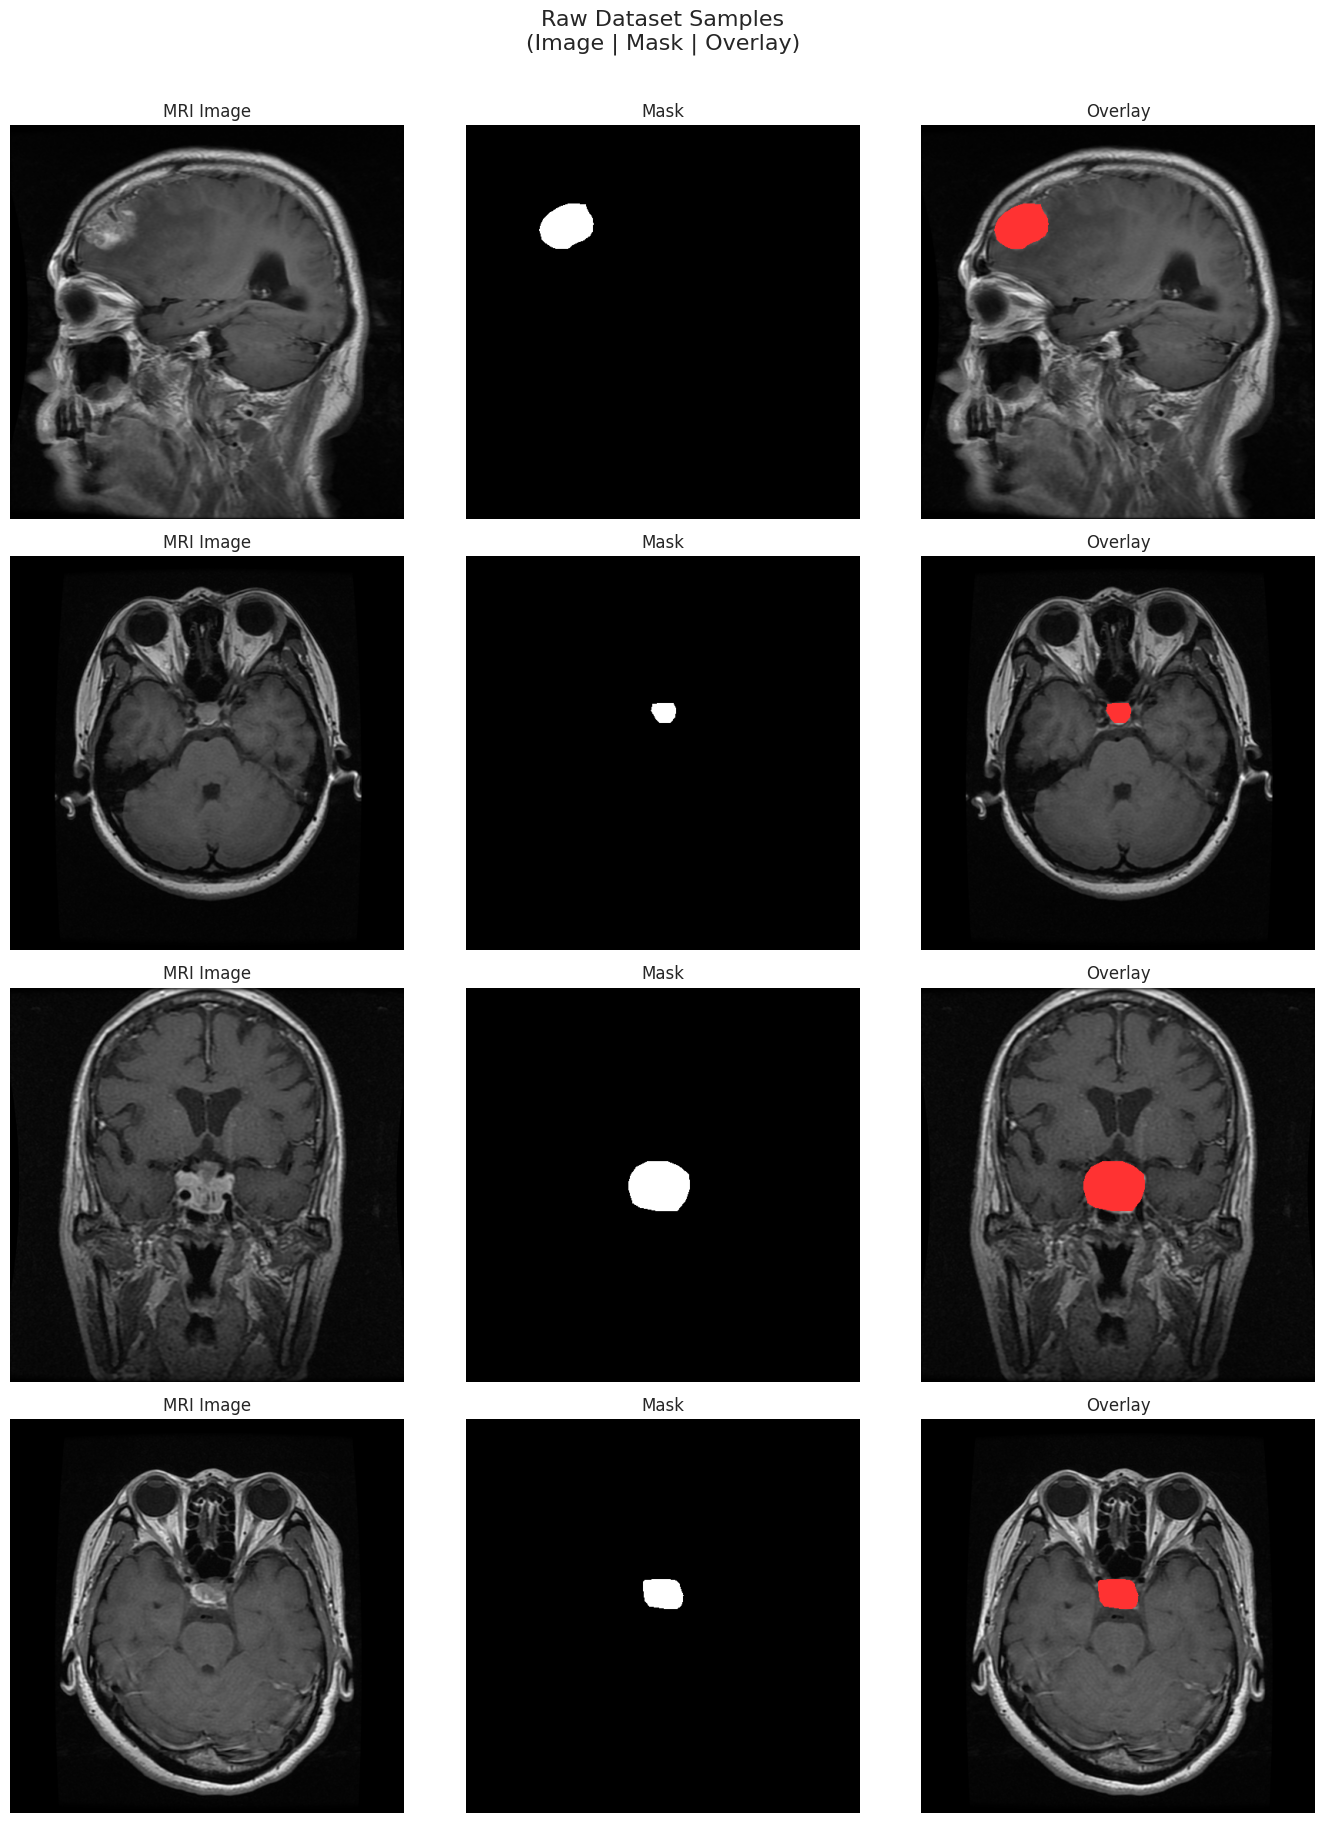

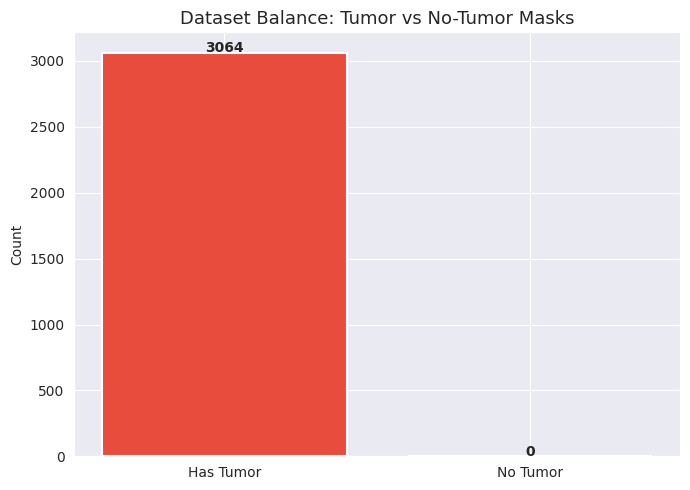

Tumor    : 3064 (100.0%)
No-tumor : 0 (0.0%)


In [8]:
#  Visualise a few raw samples
sample_names = random.sample(image_files, 4)

fig, axes = plt.subplots(4, 3, figsize=(14, 18))
fig.suptitle('Raw Dataset Samples\n(Image | Mask | Overlay)', fontsize=16, y=1.01)

for i, name in enumerate(sample_names):
    img  = cv2.cvtColor(cv2.imread(os.path.join(IMAGES_PATH, name)), cv2.COLOR_BGR2RGB)
    msk  = cv2.imread(os.path.join(MASKS_PATH, name), cv2.IMREAD_GRAYSCALE)

    axes[i, 0].imshow(img);  axes[i, 0].set_title('MRI Image');  axes[i, 0].axis('off')
    axes[i, 1].imshow(msk, cmap='gray'); axes[i, 1].set_title('Mask'); axes[i, 1].axis('off')

    overlay = img.copy()
    overlay[msk > 0] = [255, 50, 50]          # highlight tumour in red
    axes[i, 2].imshow(overlay); axes[i, 2].set_title('Overlay'); axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

# Tumour-presence stats
has_tumor, no_tumor = 0, 0
for name in mask_files:
    msk = cv2.imread(os.path.join(MASKS_PATH, name), cv2.IMREAD_GRAYSCALE)
    (has_tumor if msk.max() > 0 else no_tumor).__class__  # dummy
    if msk.max() > 0: has_tumor += 1
    else:             no_tumor  += 1

labels = ['Has Tumor', 'No Tumor']
sizes  = [has_tumor, no_tumor]
colors = ['#e74c3c', '#2ecc71']

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(labels, sizes, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(ax.patches, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', fontweight='bold')
ax.set_title('Dataset Balance: Tumor vs No-Tumor Masks', fontsize=13)
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()
print(f'Tumor    : {has_tumor} ({100*has_tumor/len(mask_files):.1f}%)')
print(f'No-tumor : {no_tumor} ({100*no_tumor/len(mask_files):.1f}%)')

## Step 5: Advanced Preprocessing Pipeline


In [9]:
def apply_clahe(img_rgb):
    """CLAHE on L-channel (LAB space) → improves local contrast."""
    lab   = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)


def remove_noise(img_rgb, kernel_size=3):
    """Mild Gaussian blur to reduce sensor noise."""
    return cv2.GaussianBlur(img_rgb, (kernel_size, kernel_size), 0)


def preprocess_image(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH),
                     use_clahe=True, use_denoise=True):
    """Full image preprocessing pipeline."""
    # 1. Load
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

    # 2. Resize to original target then crop
    img = cv2.resize(img, (512, 512))
    img = img[CROP_Y1:CROP_Y2, CROP_X1:CROP_X2]

    # 3. Resize to model input
    img = cv2.resize(img, target_size)

    # 4. Denoise
    if use_denoise:
        img = remove_noise(img)

    # 5. CLAHE contrast enhancement
    if use_clahe:
        img = apply_clahe(img)

    # 6. Normalize to [0, 1]
    img = img.astype(np.float32) / 255.0

    return img


def preprocess_mask(mask_path, target_size=(IMG_HEIGHT, IMG_WIDTH)):
    """Full mask preprocessing pipeline."""
    # 1. Load grayscale
    msk = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # 2. Resize then crop
    msk = cv2.resize(msk, (512, 512))
    msk = msk[CROP_Y1:CROP_Y2, CROP_X1:CROP_X2]

    # 3. Resize to model output size
    msk = cv2.resize(msk, target_size, interpolation=cv2.INTER_NEAREST)

    # 4. Binarize (0 or 1)
    msk = (msk > 127).astype(np.float32)

    # 5. Add channel dimension
    return msk[:, :, np.newaxis]


print(' Preprocessing functions defined!')

 Preprocessing functions defined!


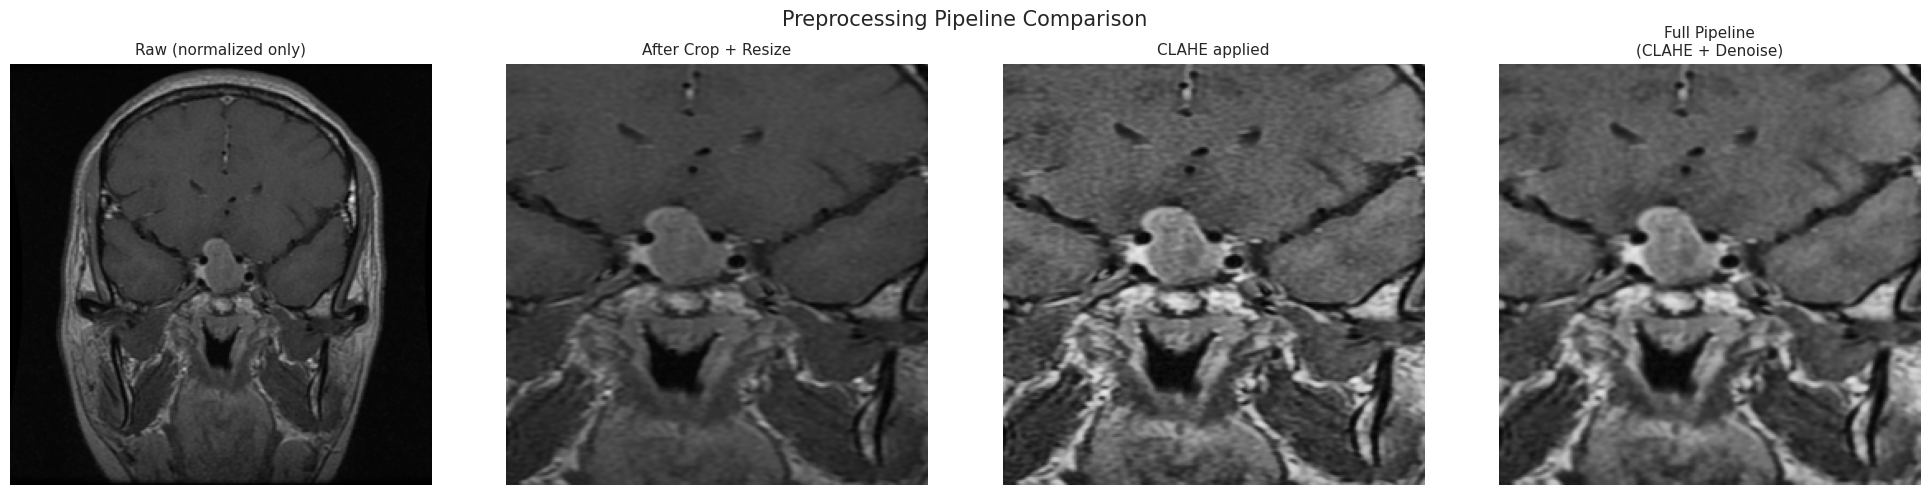

In [10]:
#  Visualise preprocessing effect
sample = image_files[50]
raw_img = cv2.cvtColor(cv2.imread(os.path.join(IMAGES_PATH, sample)), cv2.COLOR_BGR2RGB)
raw_img_resized = cv2.resize(raw_img, (IMG_WIDTH, IMG_HEIGHT))

img_no_clahe    = preprocess_image(os.path.join(IMAGES_PATH, sample), use_clahe=False, use_denoise=False)
img_clahe_only  = preprocess_image(os.path.join(IMAGES_PATH, sample), use_clahe=True,  use_denoise=False)
img_full_pipe   = preprocess_image(os.path.join(IMAGES_PATH, sample), use_clahe=True,  use_denoise=True)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Preprocessing Pipeline Comparison', fontsize=15)
titles = ['Raw (normalized only)', 'After Crop + Resize', 'CLAHE applied', 'Full Pipeline\n(CLAHE + Denoise)']
imgs   = [raw_img_resized / 255.0, img_no_clahe, img_clahe_only, img_full_pipe]

for ax, title, im in zip(axes, titles, imgs):
    ax.imshow(im)
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Step 6: Train / Validation / Test Split

In [11]:
all_ids = sorted(image_files)

# 80 / 10 / 10 split
train_ids, temp_ids = train_test_split(all_ids, test_size=0.2, random_state=SEED)
val_ids,   test_ids = train_test_split(temp_ids, test_size=0.5, random_state=SEED)

print(f'Train : {len(train_ids):>4} images')
print(f'Val   : {len(val_ids):>4} images')
print(f'Test  : {len(test_ids):>4} images')

Train : 2451 images
Val   :  306 images
Test  :  307 images


##  Step 7: Data Augmentation

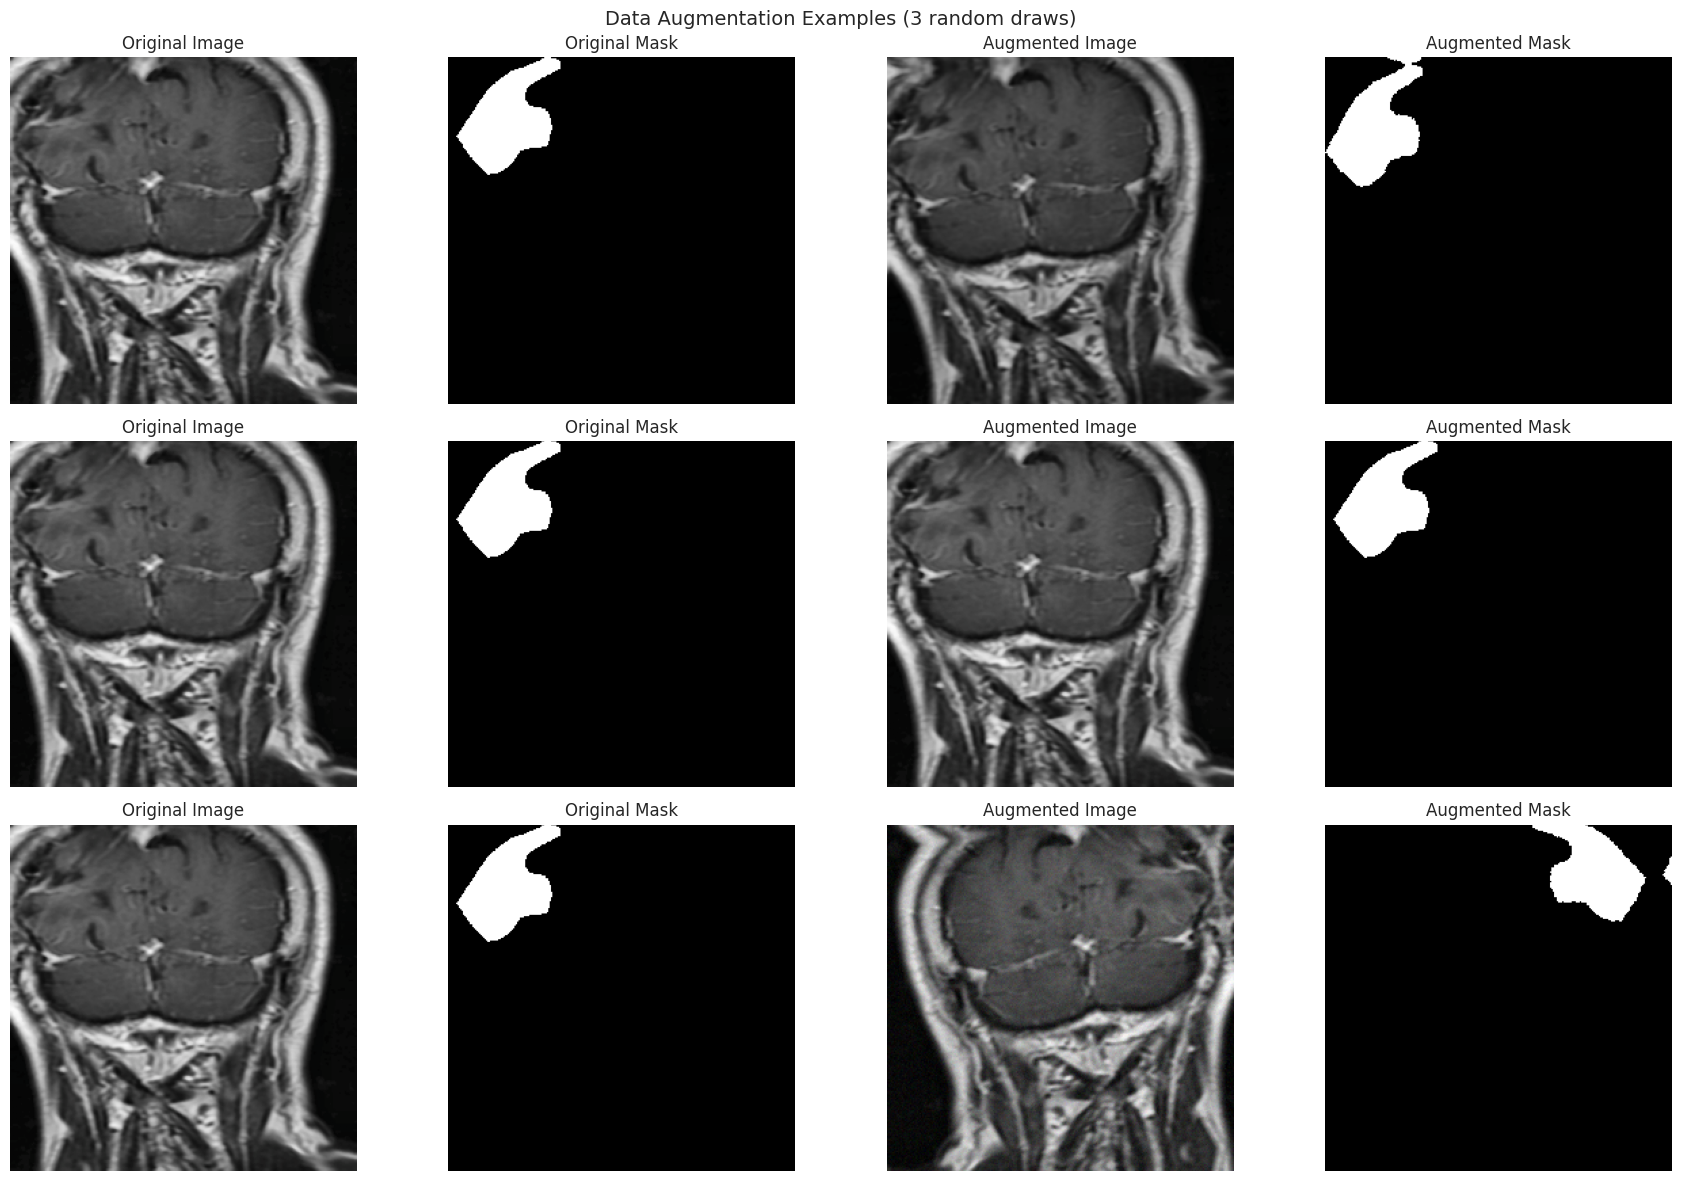

In [12]:
def augment_pair(img, msk):
    """
    Apply IDENTICAL random transforms to image and mask.
    All ops are NumPy / OpenCV — no keras dependency.
    """
    h, w = img.shape[:2]

    # 1. Horizontal flip (50 %)
    if random.random() > 0.5:
        img = cv2.flip(img, 1)
        msk = cv2.flip(msk[:, :, 0], 1)[:, :, np.newaxis]

    # 2. Vertical flip (30 %)
    if random.random() > 0.7:
        img = cv2.flip(img, 0)
        msk = cv2.flip(msk[:, :, 0], 0)[:, :, np.newaxis]

    # 3. Random rotation ±15°
    if random.random() > 0.5:
        angle = random.uniform(-15, 15)
        M   = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
        img = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR,
                             borderMode=cv2.BORDER_REFLECT)
        msk_2d = cv2.warpAffine(msk[:, :, 0], M, (w, h),
                                flags=cv2.INTER_NEAREST,
                                borderMode=cv2.BORDER_REFLECT)
        msk = msk_2d[:, :, np.newaxis]

    # 4. Brightness / contrast jitter (image only)
    if random.random() > 0.5:
        alpha = random.uniform(0.85, 1.15)   # contrast
        beta  = random.uniform(-0.05, 0.05)  # brightness
        img   = np.clip(img * alpha + beta, 0.0, 1.0).astype(np.float32)

    # 5. Gaussian noise (image only)
    if random.random() > 0.7:
        noise = np.random.normal(0, 0.02, img.shape).astype(np.float32)
        img   = np.clip(img + noise, 0.0, 1.0)

    return img, msk


# ── Show augmentation examples ─────────────────────────────────
sample_img  = preprocess_image(os.path.join(IMAGES_PATH, train_ids[10]))
sample_msk  = preprocess_mask (os.path.join(MASKS_PATH,  train_ids[10]))

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Data Augmentation Examples (3 random draws)', fontsize=14)

for row in range(3):
    aug_img, aug_msk = augment_pair(sample_img.copy(), sample_msk.copy())
    axes[row, 0].imshow(sample_img);       axes[row, 0].set_title('Original Image'); axes[row, 0].axis('off')
    axes[row, 1].imshow(sample_msk[:, :, 0], cmap='gray'); axes[row, 1].set_title('Original Mask'); axes[row, 1].axis('off')
    axes[row, 2].imshow(aug_img);          axes[row, 2].set_title('Augmented Image'); axes[row, 2].axis('off')
    axes[row, 3].imshow(aug_msk[:, :, 0], cmap='gray');    axes[row, 3].set_title('Augmented Mask'); axes[row, 3].axis('off')

plt.tight_layout()
plt.show()

##  Step 8: Build tf.data Pipelines

In [14]:
def load_and_preprocess(img_id):
    img_id  = img_id.numpy().decode('utf-8')
    img     = preprocess_image(os.path.join(IMAGES_PATH, img_id))
    msk     = preprocess_mask (os.path.join(MASKS_PATH,  img_id))
    return img, msk


def load_and_augment(img_id):
    img_id  = img_id.numpy().decode('utf-8')
    img     = preprocess_image(os.path.join(IMAGES_PATH, img_id))
    msk     = preprocess_mask (os.path.join(MASKS_PATH,  img_id))
    img, msk = augment_pair(img, msk)
    return img.astype(np.float32), msk.astype(np.float32)


def make_dataset(ids, augment=False, shuffle=False):
    fn = load_and_augment if augment else load_and_preprocess
    ds = tf.data.Dataset.from_tensor_slices(ids)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(ids), seed=SEED)
    ds = ds.map(
        lambda x: tf.py_function(fn, [x], [tf.float32, tf.float32]),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    ds = ds.map(lambda img, msk: (
        tf.ensure_shape(img, [IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS]),
        tf.ensure_shape(msk, [IMG_HEIGHT, IMG_WIDTH, 1])
    ))
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(train_ids, augment=True,  shuffle=True)
val_ds   = make_dataset(val_ids,   augment=False, shuffle=False)
test_ds  = make_dataset(test_ids,  augment=False, shuffle=False)

print(' tf.data pipelines ready!')
print(f'   Train batches : {len(train_ds)}')
print(f'   Val   batches : {len(val_ds)}')
print(f'   Test  batches : {len(test_ds)}')

 tf.data pipelines ready!
   Train batches : 154
   Val   batches : 20
   Test  batches : 20


##  Step 9: Custom Metrics & Loss


In [16]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """Dice = 2 * |A ∩ B| / (|A| + |B|)"""
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )


def dice_loss(y_true, y_pred, smooth=1e-6):
    intersection = tf.reduce_sum(y_true * y_pred)
    return 1.0 - (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )


def combined_loss(y_true, y_pred):
    """BCE + Dice – best of both worlds."""
    bce  = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return bce + dice


def iou_score(y_true, y_pred, smooth=1e-6):
    """Intersection over Union (Jaccard Index)"""
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)


print(' Custom metrics defined: Dice Coefficient, Dice Loss, Combined Loss, IoU')

 Custom metrics defined: Dice Coefficient, Dice Loss, Combined Loss, IoU


##  Step 10: U-Net Architecture (Enhanced)

In [17]:
def conv_block(x, filters, dropout_rate=0.1):
    """Double Conv → BN → ReLU block (encoder building block)."""
    x = tf.keras.layers.Conv2D(filters, (3, 3), padding='same',
                               kernel_initializer='he_normal')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    x = tf.keras.layers.Conv2D(filters, (3, 3), padding='same',
                               kernel_initializer='he_normal')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    return x


def build_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)):
    inputs = tf.keras.layers.Input(input_shape)

    #  Encoder
    c1 = conv_block(inputs, 16,  dropout_rate=0.1);  p1 = tf.keras.layers.MaxPooling2D((2, 2))(c1)
    c2 = conv_block(p1,     32,  dropout_rate=0.1);  p2 = tf.keras.layers.MaxPooling2D((2, 2))(c2)
    c3 = conv_block(p2,     64,  dropout_rate=0.2);  p3 = tf.keras.layers.MaxPooling2D((2, 2))(c3)
    c4 = conv_block(p3,     128, dropout_rate=0.2);  p4 = tf.keras.layers.MaxPooling2D((2, 2))(c4)

    #  Bottleneck
    c5 = conv_block(p4, 256, dropout_rate=0.3)

    # Decoder
    u6 = tf.keras.layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = tf.keras.layers.concatenate([u6, c4])
    c6 = conv_block(u6, 128, dropout_rate=0.2)

    u7 = tf.keras.layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = tf.keras.layers.concatenate([u7, c3])
    c7 = conv_block(u7, 64, dropout_rate=0.2)

    u8 = tf.keras.layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = tf.keras.layers.concatenate([u8, c2])
    c8 = conv_block(u8, 32, dropout_rate=0.1)

    u9 = tf.keras.layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = tf.keras.layers.concatenate([u9, c1], axis=3)
    c9 = conv_block(u9, 16, dropout_rate=0.1)

    outputs = tf.keras.layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = tf.keras.Model(inputs, outputs, name='UNet_Enhanced')
    return model


model = build_unet()
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss=combined_loss,
    metrics=['accuracy', dice_coefficient, iou_score]
)
model.summary()

Model: "UNet_Enhanced"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256, 256,  │          0 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      2,320 │ dropout[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128, 128,  │          0 │ activation_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │      9,248 │ dropout_1[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][

 Total params: 1,946,993 (7.43 MB)

 Trainable params: 1,944,049 (7.42 MB)

 Non-trainable params: 2,944 (11.50 KB)

##  Step 11: Training with Smart Callbacks

In [18]:
callbacks = [
    # Stop if no improvement for 5 epochs
    EarlyStopping(
        monitor='val_dice_coefficient',
        patience=5,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    # Save best model automatically
    ModelCheckpoint(
        'best_brain_tumor_model.h5',
        monitor='val_dice_coefficient',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    # Reduce LR when plateau
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
]

print(' Callbacks ready!')
print(' - EarlyStopping    (patience=5, monitors Dice)')
print(' - ModelCheckpoint  (saves best model)')
print(' - ReduceLROnPlateau (halves LR on plateau)')

 Callbacks ready!
 - EarlyStopping    (patience=5, monitors Dice)
 - ModelCheckpoint  (saves best model)
 - ReduceLROnPlateau (halves LR on plateau)


In [19]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.6975 - dice_coefficient: 0.1096 - iou_score: 0.0584 - loss: 1.5376
Epoch 1: val_dice_coefficient improved from None to 0.19363, saving model to best_brain_tumor_model.h5



Epoch 1: finished saving model to best_brain_tumor_model.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 138s 496ms/step - accuracy: 0.8135 - dice_coefficient: 0.1482 - iou_score: 0.0816 - loss: 1.4402 - val_accuracy: 0.8914 - val_dice_coefficient: 0.1936 - val_iou_score: 0.1088 - val_loss: 1.4969 - learning_rate: 1.0000e-04
Epoch 2/30
153/154 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.9512 - dice_coefficient: 0.3566 - iou_score: 0.2210 - loss: 1.2392
Epoch 2: val_dice_coefficient improved from 0.19363 to 0.22963, saving model to best_brain_tumor_model.h5



Epoch 2: finished saving model to best_brain_tumor_model.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 52s 337ms/step - accuracy: 0.9543 - dice_coefficient: 0.4087 - iou_score: 0.2618 - loss: 1.2056 - val_accuracy: 0.8983 - val_dice_coefficient: 0.2296 - val_iou_score: 0.1358 - val_loss: 1.3927 - learning_rate: 1.0000e-04
Epoch 3/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.9545 - dice_coefficient: 0.4877 - iou_score: 0.3262 - loss: 1.1282
Epoch 3: val_dice_coefficient improved from 0.22963 to 0.38714, saving model to best_brain_tumor_model.h5



Epoch 3: finished saving model to best_brain_tumor_model.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 50s 326ms/step - accuracy: 0.9553 - dice_coefficient: 0.5079 - iou_score: 0.3447 - loss: 1.1040 - val_accuracy: 0.9541 - val_dice_coefficient: 0.3871 - val_iou_score: 0.2512 - val_loss: 1.1075 - learning_rate: 1.0000e-04
Epoch 4/30
153/154 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.9579 - dice_coefficient: 0.5594 - iou_score: 0.3917 - loss: 1.0389
Epoch 4: val_dice_coefficient improved from 0.38714 to 0.47670, saving model to best_brain_tumor_model.h5



Epoch 4: finished saving model to best_brain_tumor_model.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 50s 325ms/step - accuracy: 0.9583 - dice_coefficient: 0.5639 - iou_score: 0.3960 - loss: 1.0256 - val_accuracy: 0.9369 - val_dice_coefficient: 0.4767 - val_iou_score: 0.3155 - val_loss: 1.0605 - learning_rate: 1.0000e-04
Epoch 5/30
153/154 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.9584 - dice_coefficient: 0.5697 - iou_score: 0.4033 - loss: 0.9862
Epoch 5: val_dice_coefficient improved from 0.47670 to 0.53786, saving model to best_brain_tumor_model.h5


...


Epoch 19: finished saving model to best_brain_tumor_model.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 50s 324ms/step - accuracy: 0.9757 - dice_coefficient: 0.7346 - iou_score: 0.5857 - loss: 0.4759 - val_accuracy: 0.9746 - val_dice_coefficient: 0.7070 - val_iou_score: 0.5546 - val_loss: 0.5119 - learning_rate: 5.0000e-05
Epoch 20/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.9761 - dice_coefficient: 0.7381 - iou_score: 0.5891 - loss: 0.4663
Epoch 20: val_dice_coefficient did not improve from 0.70703
154/154 ━━━━━━━━━━━━━━━━━━━━ 52s 337ms/step - accuracy: 0.9757 - dice_coefficient: 0.7339 - iou_score: 0.5844 - loss: 0.4678 - val_accuracy: 0.9719 - val_dice_coefficient: 0.6846 - val_iou_score: 0.5263 - val_loss: 0.5227 - learning_rate: 5.0000e-05
Epoch 21/30
153/154 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.9761 - dice_coefficient: 0.7386 - iou_score: 0.5891 - loss: 0.4573
Epoch 21: val_dice_coefficient improved from 0.70703 to 0.71277, saving model to best_brain_tumor_model.h5


Epoch 21: finished saving model to best_brain_tumor_model.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 50s 327ms/step - accuracy: 0.9764 - dice_coefficient: 0.7429 - iou_score: 0.5947 - loss: 0.4522 - val_accuracy: 0.9753 - val_dice_coefficient: 0.7128 - val_iou_score: 0.5619 - val_loss: 0.4893 - learning_rate: 5.0000e-05
Epoch 22/30
153/154 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.9765 - dice_coefficient: 0.7428 - iou_score: 0.5949 - loss: 0.4478
Epoch 22: val_dice_coefficient did not improve from 0.71277
154/154 ━━━━━━━━━━━━━━━━━━━━ 50s 327ms/step - accuracy: 0.9764 - dice_coefficient: 0.7395 - iou_score: 0.5917 - loss: 0.4494 - val_accuracy: 0.9725 - val_dice_coefficient: 0.6518 - val_iou_score: 0.4932 - val_loss: 0.5265 - learning_rate: 5.0000e-05
Epoch 23/30
153/154 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.9776 - dice_coefficient: 0.7551 - iou_score: 0.6109 - loss: 0.4261
Epoch 23: val_dice_coefficient did not improve from 0.71277
154/154 ━━━━━━━━━━━━━━━━━━━━ 50s 328ms/step - 


Epoch 24: finished saving model to best_brain_tumor_model.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 51s 328ms/step - accuracy: 0.9772 - dice_coefficient: 0.7506 - iou_score: 0.6049 - loss: 0.4257 - val_accuracy: 0.9745 - val_dice_coefficient: 0.7288 - val_iou_score: 0.5800 - val_loss: 0.4549 - learning_rate: 5.0000e-05
Epoch 25/30
153/154 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.9777 - dice_coefficient: 0.7525 - iou_score: 0.6066 - loss: 0.4187
Epoch 25: val_dice_coefficient did not improve from 0.72875
154/154 ━━━━━━━━━━━━━━━━━━━━ 82s 331ms/step - accuracy: 0.9774 - dice_coefficient: 0.7485 - iou_score: 0.6017 - loss: 0.4224 - val_accuracy: 0.9751 - val_dice_coefficient: 0.6970 - val_iou_score: 0.5413 - val_loss: 0.4692 - learning_rate: 5.0000e-05
Epoch 26/30
153/154 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.9769 - dice_coefficient: 0.7419 - iou_score: 0.5931 - loss: 0.4274
Epoch 26: val_dice_coefficient did not improve from 0.72875
154/154 ━━━━━━━━━━━━━━━━━━━━ 81s 326ms/step - 


Epoch 29: finished saving model to best_brain_tumor_model.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 51s 327ms/step - accuracy: 0.9779 - dice_coefficient: 0.7553 - iou_score: 0.6108 - loss: 0.3956 - val_accuracy: 0.9772 - val_dice_coefficient: 0.7424 - val_iou_score: 0.5961 - val_loss: 0.4162 - learning_rate: 5.0000e-05
Epoch 30/30
153/154 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.9782 - dice_coefficient: 0.7540 - iou_score: 0.6094 - loss: 0.3958
Epoch 30: val_dice_coefficient improved from 0.74236 to 0.74825, saving model to best_brain_tumor_model.h5



Epoch 30: finished saving model to best_brain_tumor_model.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 83s 333ms/step - accuracy: 0.9785 - dice_coefficient: 0.7586 - iou_score: 0.6150 - loss: 0.3879 - val_accuracy: 0.9771 - val_dice_coefficient: 0.7483 - val_iou_score: 0.6050 - val_loss: 0.4058 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 30.


##  Step 12: Training Visualization

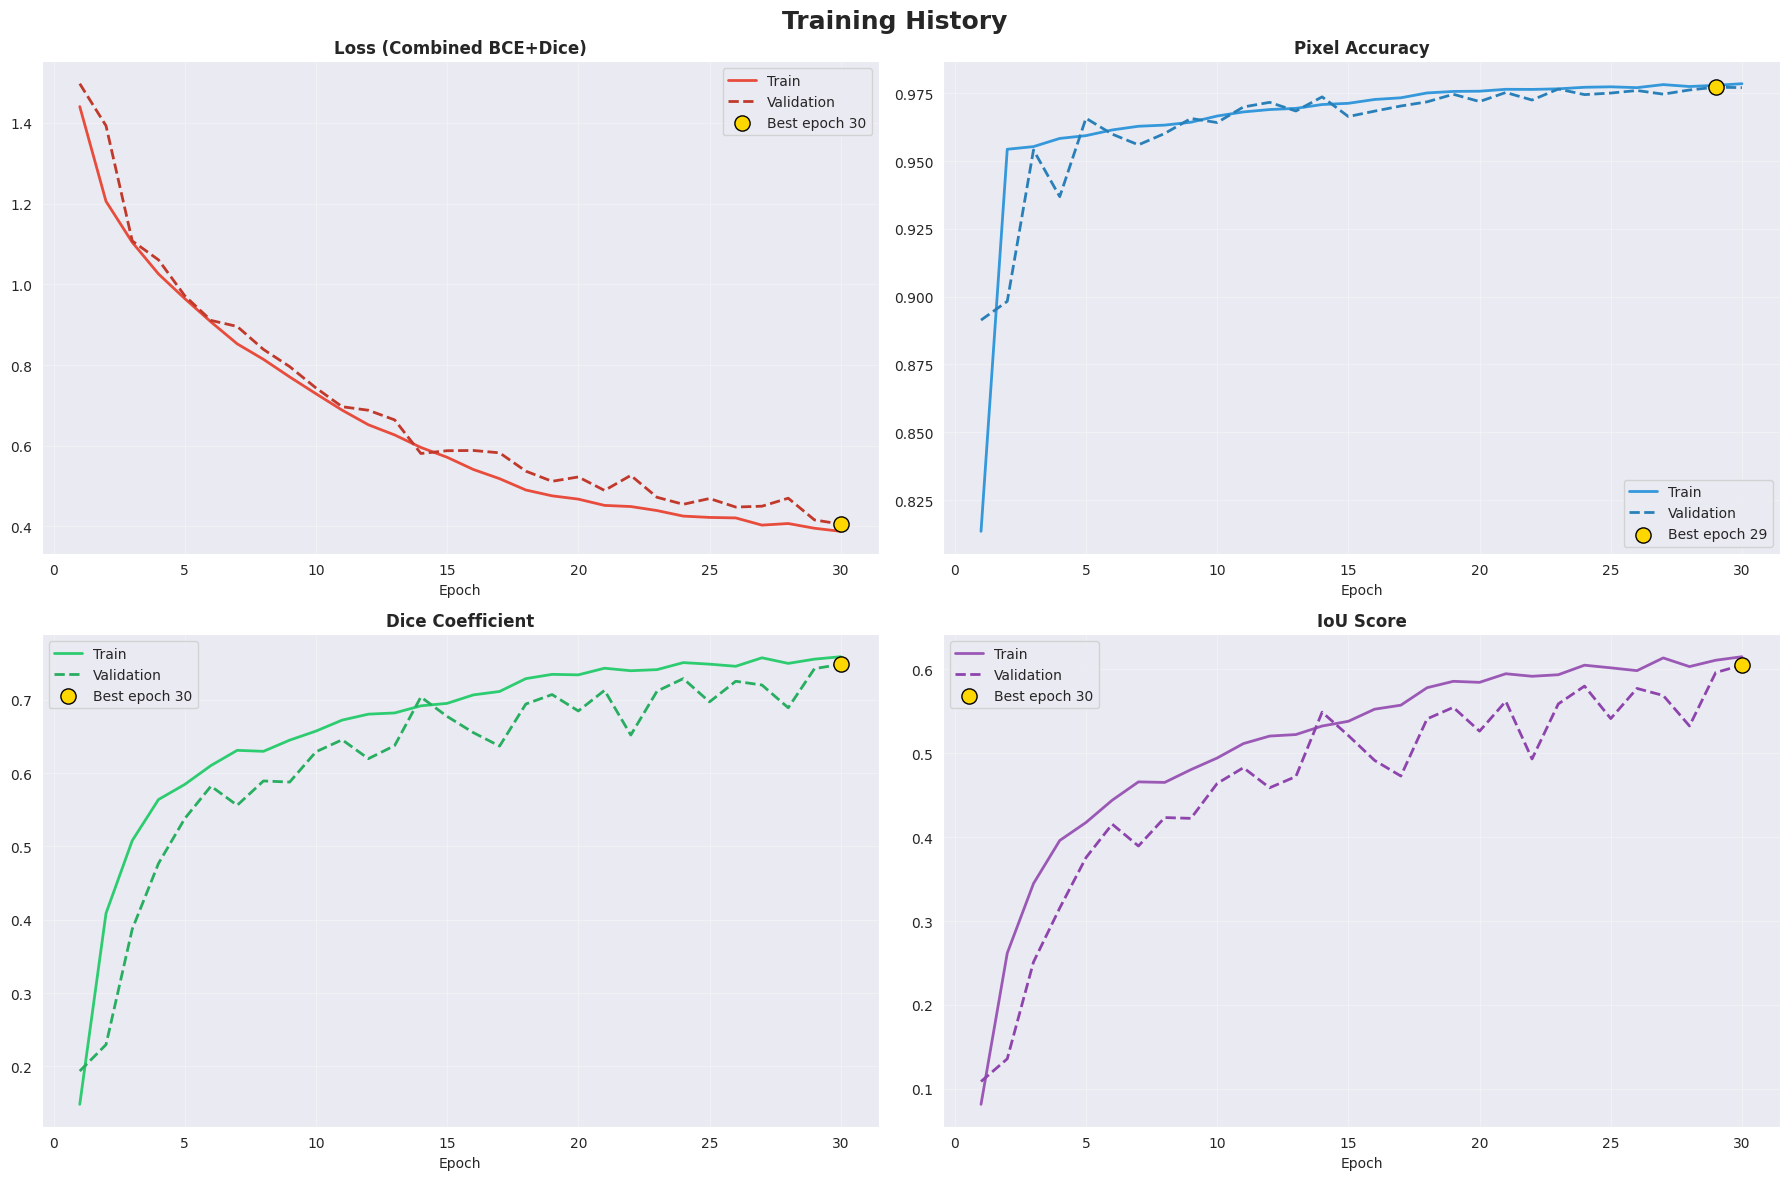

In [20]:
def plot_training(hist):
    metrics  = ['loss', 'accuracy', 'dice_coefficient', 'iou_score']
    titles   = ['Loss (Combined BCE+Dice)', 'Pixel Accuracy', 'Dice Coefficient', 'IoU Score']
    colors   = [('#e74c3c', '#c0392b'), ('#3498db', '#2980b9'),
                ('#2ecc71', '#27ae60'), ('#9b59b6', '#8e44ad')]

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Training History', fontsize=18, fontweight='bold')
    axes = axes.flatten()

    for ax, metric, title, (c_tr, c_val) in zip(axes, metrics, titles, colors):
        if metric not in hist.history:
            ax.set_visible(False)
            continue
        tr_vals  = hist.history[metric]
        val_vals = hist.history.get(f'val_{metric}', [])
        epochs_x = range(1, len(tr_vals) + 1)

        ax.plot(epochs_x, tr_vals,  color=c_tr,  lw=2, label='Train')
        if val_vals:
            ax.plot(epochs_x, val_vals, color=c_val, lw=2, label='Validation', linestyle='--')
            best_idx = (np.argmin if 'loss' in metric else np.argmax)(val_vals)
            ax.scatter(best_idx + 1, val_vals[best_idx], s=120, zorder=5,
                       color='gold', edgecolor='black', label=f'Best epoch {best_idx+1}')
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training(history)

##  Step 13: Evaluation on Test Set

In [21]:
print('Evaluating on held-out test set...')
test_results = model.evaluate(test_ds, verbose=1)
metric_names = ['Loss', 'Accuracy', 'Dice Coefficient', 'IoU Score']

print('\n' + '='*45)
print('         TEST SET RESULTS')
print('='*45)
for name, val in zip(metric_names, test_results):
    print(f'  {name:<20} : {val:.4f}')
print('='*45)

Evaluating on held-out test set...
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 199ms/step - accuracy: 0.9753 - dice_coefficient: 0.7221 - iou_score: 0.5698 - loss: 0.4275

         TEST SET RESULTS
  Loss                 : 0.4275
  Accuracy             : 0.9753
  Dice Coefficient     : 0.7221
  IoU Score            : 0.5698


##  Step 14: Qualitative Results & Threshold Analysis

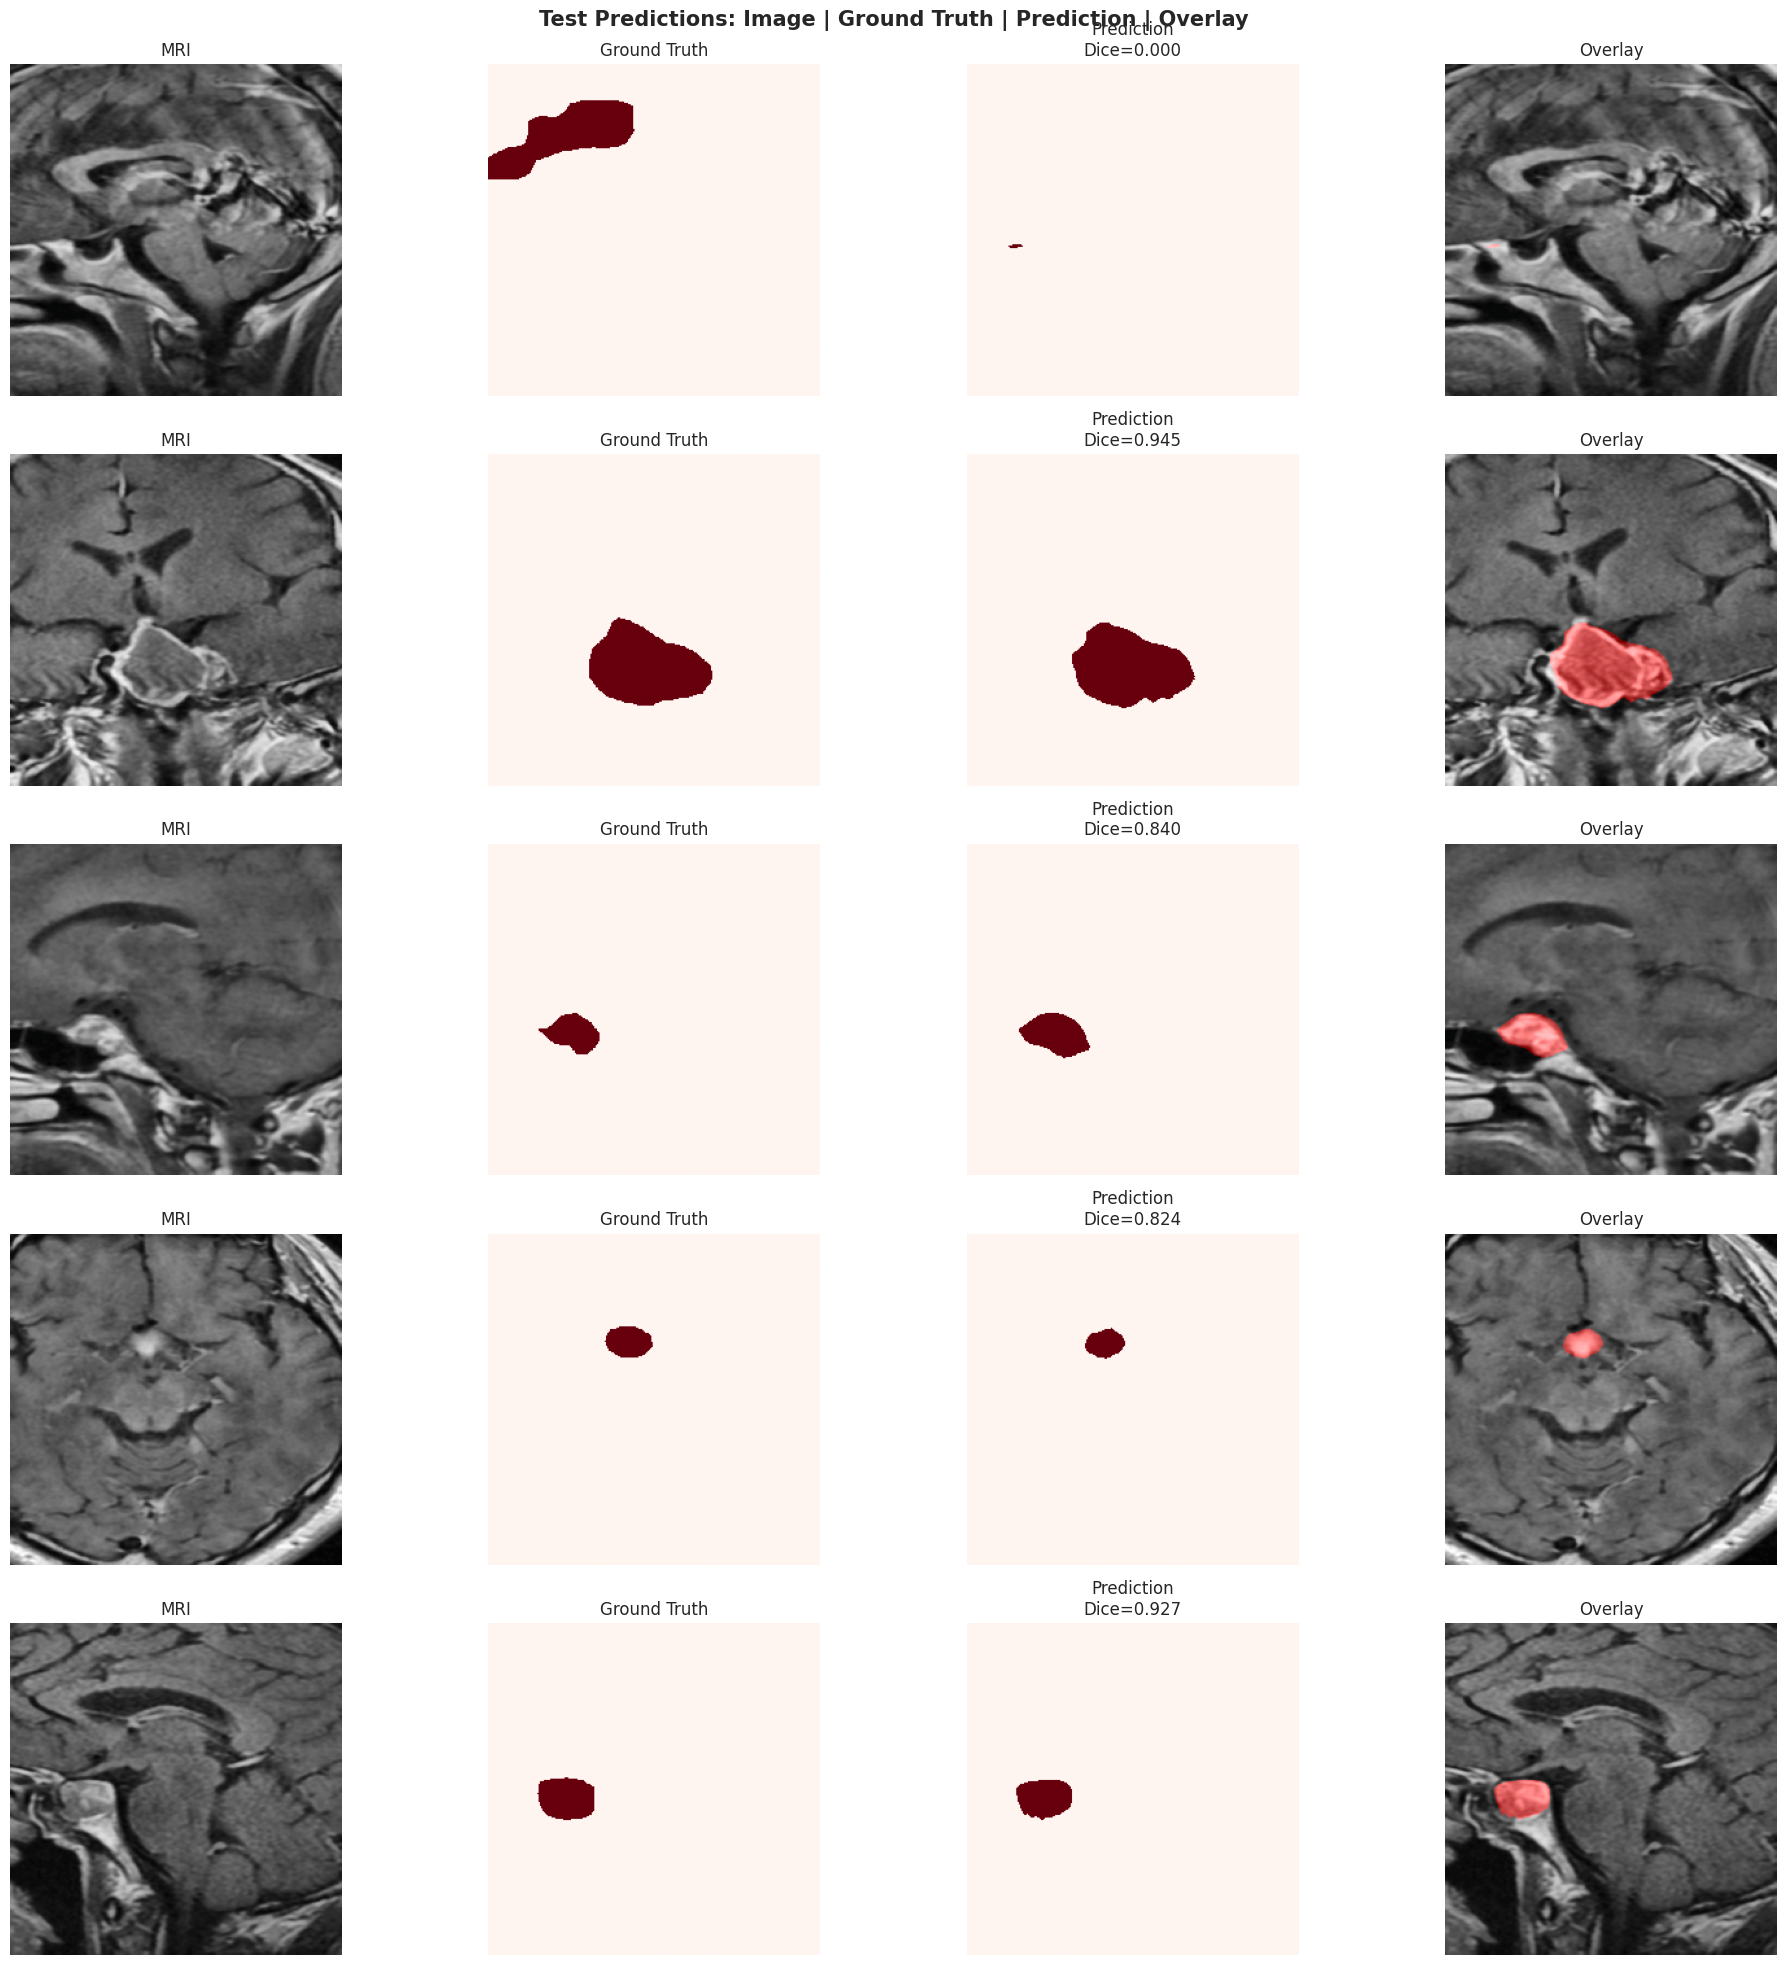

In [22]:
# Qualitative prediction visualization
n_samples = 5
sample_imgs, sample_msks = [], []

for name in test_ids[:n_samples]:
    sample_imgs.append(preprocess_image(os.path.join(IMAGES_PATH, name)))
    sample_msks.append(preprocess_mask (os.path.join(MASKS_PATH,  name)))

X_test_sample = np.array(sample_imgs)
y_test_sample = np.array(sample_msks)
preds = model.predict(X_test_sample, verbose=0)

fig, axes = plt.subplots(n_samples, 4, figsize=(20, n_samples * 4))
fig.suptitle('Test Predictions: Image | Ground Truth | Prediction | Overlay',
             fontsize=15, fontweight='bold')

for i in range(n_samples):
    pred_bin = (preds[i, :, :, 0] > 0.5).astype(np.float32)
    true_bin = y_test_sample[i, :, :, 0]

    overlay = sample_imgs[i].copy()
    overlay[pred_bin > 0] = np.clip(overlay[pred_bin > 0] + [0.4, -0.1, -0.1], 0, 1)

    dice = (2 * (pred_bin * true_bin).sum() + 1e-6) / (pred_bin.sum() + true_bin.sum() + 1e-6)

    axes[i, 0].imshow(sample_imgs[i]);              axes[i, 0].set_title('MRI'); axes[i, 0].axis('off')
    axes[i, 1].imshow(true_bin, cmap='Reds');       axes[i, 1].set_title('Ground Truth'); axes[i, 1].axis('off')
    axes[i, 2].imshow(pred_bin, cmap='Reds');       axes[i, 2].set_title(f'Prediction\nDice={dice:.3f}'); axes[i, 2].axis('off')
    axes[i, 3].imshow(overlay);                     axes[i, 3].set_title('Overlay'); axes[i, 3].axis('off')

plt.tight_layout()
plt.show()

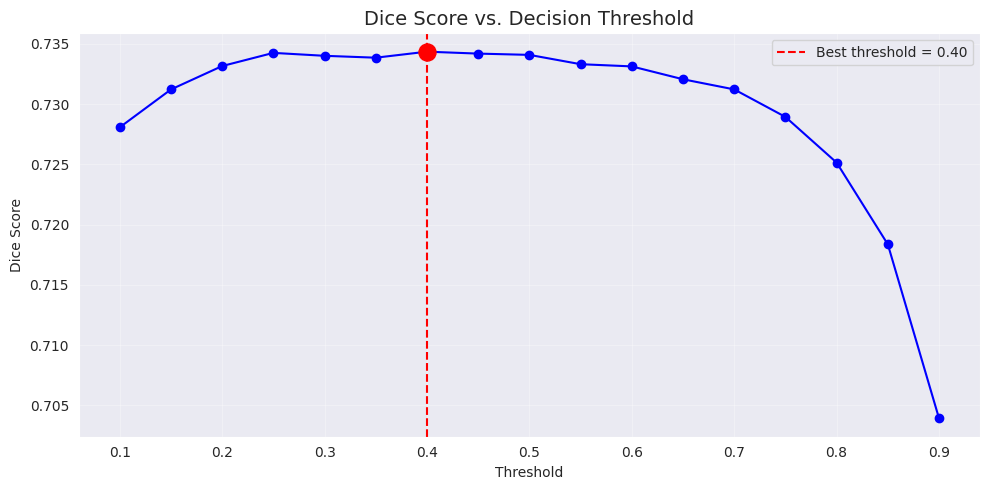

Best threshold : 0.40  →  Dice = 0.7344


In [23]:
# Threshold sweep
thresholds = np.arange(0.1, 0.95, 0.05)
dice_scores = []

for t in thresholds:
    pred_bin = (preds[:, :, :, 0] > t).astype(np.float32)
    true_bin = y_test_sample[:, :, :, 0]
    intersection = (pred_bin * true_bin).sum()
    dice = (2 * intersection + 1e-6) / (pred_bin.sum() + true_bin.sum() + 1e-6)
    dice_scores.append(dice)

best_t = thresholds[np.argmax(dice_scores)]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, dice_scores, 'b-o', markersize=6)
plt.axvline(best_t, color='red', linestyle='--', label=f'Best threshold = {best_t:.2f}')
plt.scatter([best_t], [max(dice_scores)], s=150, color='red', zorder=5)
plt.title('Dice Score vs. Decision Threshold', fontsize=14)
plt.xlabel('Threshold')
plt.ylabel('Dice Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Best threshold : {best_t:.2f}  →  Dice = {max(dice_scores):.4f}')

##  Step 15: Predict on a New Image

/tmp/ipykernel_6164/2161924508.py:19: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


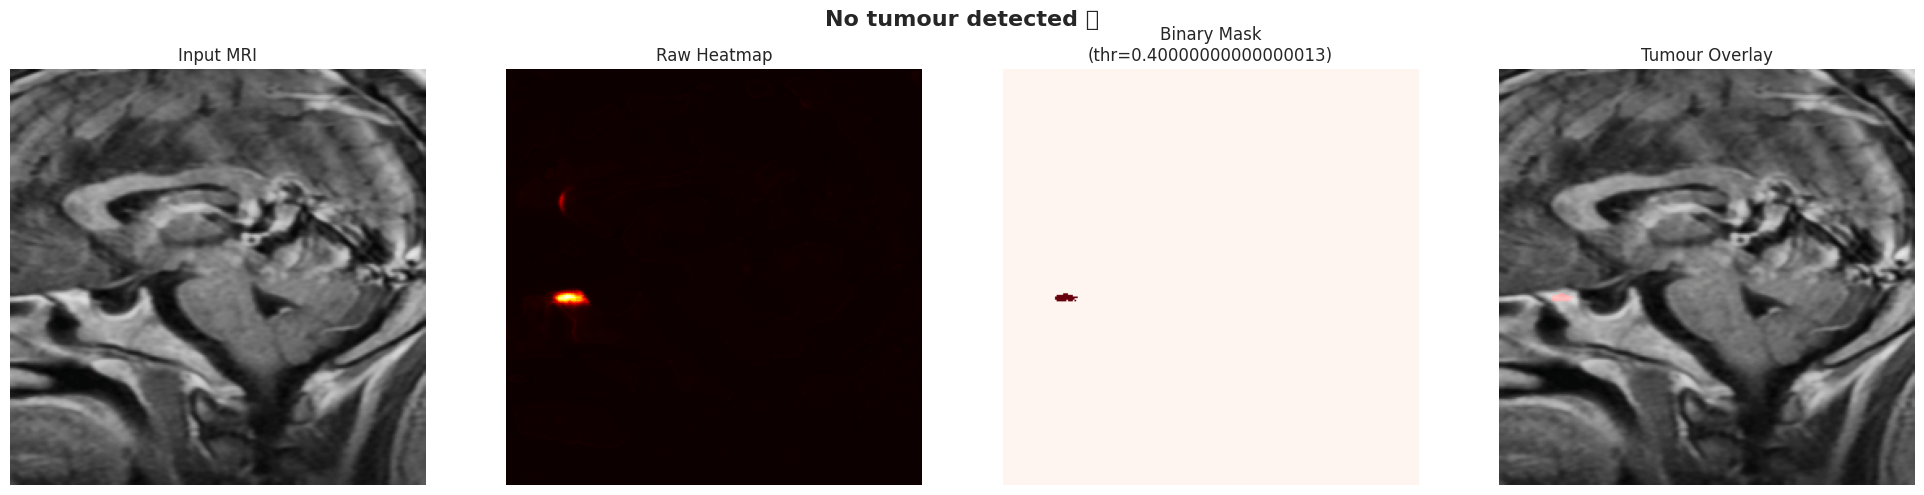

(array([[0.00765747, 0.00774239, 0.00798289, ..., 0.00704102, 0.0040689 ,
         0.00286466],
        [0.00688436, 0.00583295, 0.00592317, ..., 0.01685089, 0.00937126,
         0.00342981],
        [0.00756067, 0.0064832 , 0.00623779, ..., 0.0167111 , 0.01085831,
         0.00654737],
        ...,
        [0.0068119 , 0.0055446 , 0.00577639, ..., 0.00596279, 0.00709241,
         0.00804916],
        [0.00597276, 0.00464515, 0.00505222, ..., 0.0059753 , 0.00638191,
         0.00744688],
        [0.00629366, 0.0060921 , 0.00645379, ..., 0.00729818, 0.00754631,
         0.00744184]], dtype=float32),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32))

In [24]:
def predict_single(img_path, threshold=0.5, model=model):
    """Run the full pipeline on one image and show results."""
    img   = preprocess_image(img_path)
    batch = np.expand_dims(img, axis=0)
    pred  = model.predict(batch, verbose=0)[0, :, :, 0]
    mask  = (pred > threshold).astype(np.float32)

    overlay = img.copy()
    overlay[mask > 0] = np.clip(overlay[mask > 0] + [0.4, -0.1, -0.1], 0, 1)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(img);              axes[0].set_title('Input MRI');        axes[0].axis('off')
    axes[1].imshow(pred, cmap='hot'); axes[1].set_title('Raw Heatmap');      axes[1].axis('off')
    axes[2].imshow(mask, cmap='Reds');axes[2].set_title(f'Binary Mask\n(thr={threshold})'); axes[2].axis('off')
    axes[3].imshow(overlay);          axes[3].set_title('Tumour Overlay');   axes[3].axis('off')

    has = 'TUMOUR DETECTED 🔴' if mask.sum() > 100 else 'No tumour detected 🟢'
    fig.suptitle(has, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    return pred, mask


# Test with a sample image
predict_single(os.path.join(IMAGES_PATH, test_ids[0]), threshold=best_t)

##  Step 16: Save & Download Model

In [25]:
model.save('brain_tumor_model_enhanced.h5')
print(' Model saved as brain_tumor_model_enhanced.h5')

from google.colab import files
files.download('brain_tumor_model_enhanced.h5')
files.download('best_brain_tumor_model.h5')  # checkpoint with best weights

 Model saved as brain_tumor_model_enhanced.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>